# 08. Interpretabilidad SHAP — XGBoost (ganador del proyecto)

SHAP sobre **XGBoost-tuned-native** (58 features, AUC-PR val 0.0388, recall@top10% 0.699), que
superó al LightGBM de Fase 5. El SHAP de Fase 5 se calculo sobre LightGBM; aqui se recalcula
sobre el modelo que efectivamente entraria a produccion.

- TreeExplainer sobre `bases/modelo_fase5b_XGBoost-tuned-native.joblib`.
- Muestra: todos los positivos de train + 40k negativos (costo).
- Datos `_native` (NaN nativo, igual que en entrenamiento).
- Salidas: beeswarm, ranking mean|SHAP| vs ganancia, `bases/contribucion_xgboost.csv`,
  `bases/shap_xgboost.json`.


In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import joblib, shap, xgboost as xgb

B = "bases"; RNG = 42
model = joblib.load(f"{B}/modelo_fase5b_XGBoost-tuned-native.joblib")
nat_tr = pd.read_parquet(f"{B}/prediccion_mama_train_native.parquet")
FEAT = [c for c in nat_tr.columns if c not in ('key', 'label', 'tiene_avicena')]
y_tr = nat_tr['label'].values.astype(int)
Xn_tr = nat_tr[FEAT].astype('float32').values
assert len(FEAT) == model.n_features_in_, (len(FEAT), model.n_features_in_)
print("modelo:", type(model).__name__, "| feats:", len(FEAT), "| train pos:", int(y_tr.sum()))


modelo: XGBClassifier | feats: 58 | train pos: 1857


## 1. Calculo de valores SHAP

In [2]:
pos_idx = np.where(y_tr == 1)[0]
neg_idx = np.random.RandomState(RNG).choice(np.where(y_tr == 0)[0], 40000, replace=False)
sidx = np.concatenate([pos_idx, neg_idx])
Xs = Xn_tr[sidx]
Xs_df = pd.DataFrame(Xs, columns=FEAT)

explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(Xs_df)
if isinstance(sv, list):
    sv = sv[1]
sv = np.asarray(sv)
if sv.ndim == 3:
    sv = sv[:, :, 1]
print("SHAP values shape:", sv.shape, "| muestra:", Xs_df.shape,
      f"({len(pos_idx)} pos + {len(neg_idx)} neg)")


SHAP values shape: (41857, 58) | muestra: (41857, 58) (1857 pos + 40000 neg)


## 2. Beeswarm — direccion y magnitud por caracteristica

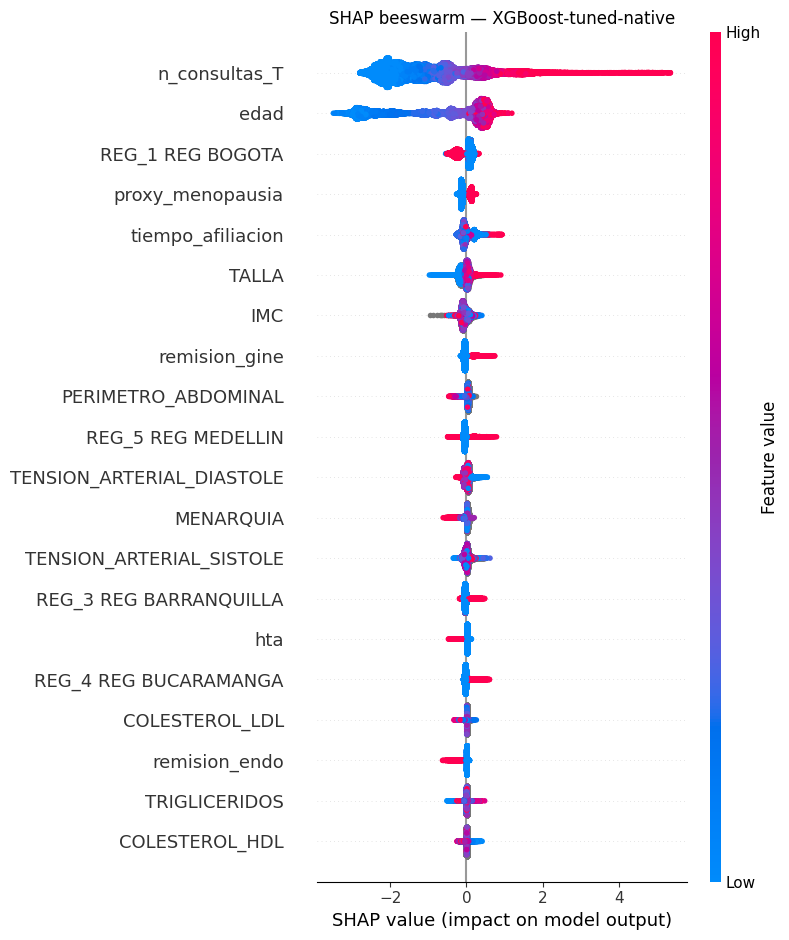

In [3]:
fig = plt.figure(figsize=(10, 9))
shap.summary_plot(sv, Xs_df, plot_type='dot', max_display=20, show=False)
plt.title('SHAP beeswarm — XGBoost-tuned-native')
plt.tight_layout(); plt.show()


## 3. Ranking mean|SHAP| vs importancia por ganancia

=== Contribucion (top 25 por mean|SHAP|) ===
                                mean_abs_SHAP  gain_norm  rank_shap
n_consultas_T                         1.29949    0.08774          1
edad                                  1.03847    0.03236          2
REG_1 REG BOGOTA                      0.15797    0.02464          3
proxy_menopausia                      0.11811    0.03414          4
tiempo_afiliacion                     0.10455    0.01113          5
TALLA                                 0.10418    0.01620          6
IMC                                   0.07915    0.01371          7
remision_gine                         0.07314    0.02432          8
PERIMETRO_ABDOMINAL                   0.06216    0.01464          9
REG_5 REG MEDELLIN                    0.05676    0.02102         10
TENSION_ARTERIAL_DIASTOLE             0.05401    0.01628         11
MENARQUIA                             0.05333    0.01479         12
TENSION_ARTERIAL_SISTOLE              0.05106    0.01544         13
REG

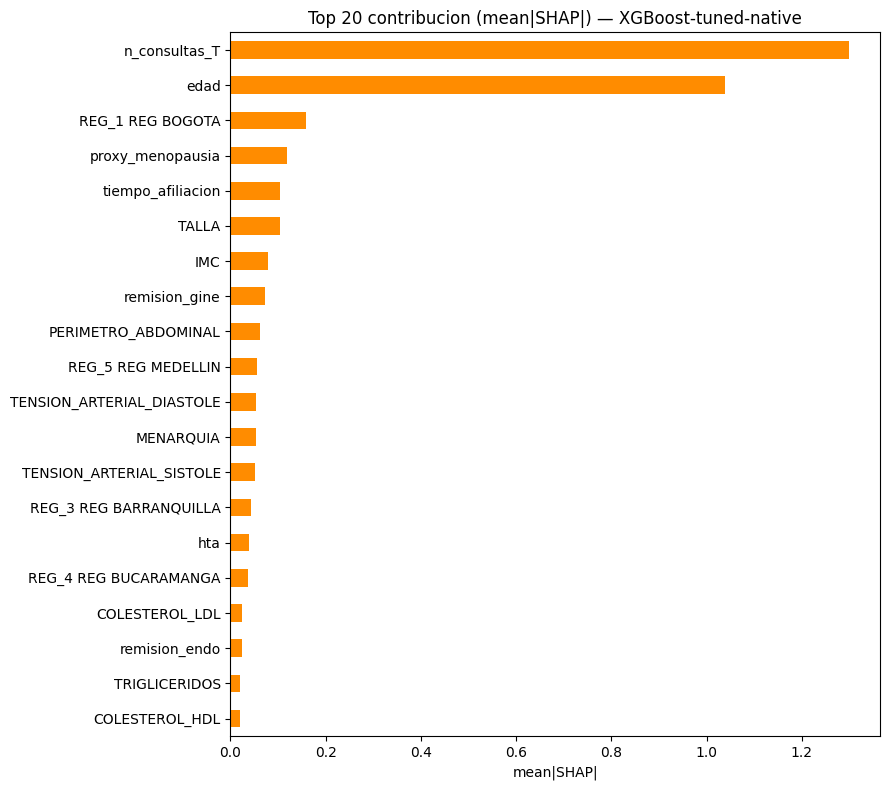

In [4]:
mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=FEAT).sort_values(ascending=False)
gain = pd.Series(model.feature_importances_, index=FEAT)
gain = (gain / gain.sum()).reindex(mean_abs.index)
contrib = pd.DataFrame({'mean_abs_SHAP': mean_abs, 'gain_norm': gain})
contrib['rank_shap'] = range(1, len(contrib) + 1)
pd.set_option('display.width', 200, 'display.max_columns', 20)
print("=== Contribucion (top 25 por mean|SHAP|) ===")
print(contrib.head(25).to_string(float_format='{:.5f}'.format))
print("\n=== Bottom 10 (aportan casi nada) ===")
print(contrib.tail(10).index.tolist())

fig, ax = plt.subplots(figsize=(9, 8))
mean_abs.head(20)[::-1].plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 20 contribucion (mean|SHAP|) — XGBoost-tuned-native'); ax.set_xlabel('mean|SHAP|')
plt.tight_layout(); plt.show()


## 4. Comparacion con SHAP de LightGBM (Fase 5)

Se contrasta el ranking del ganador actual (XGBoost) con el de LightGBM de Fase 5
(`contribucion_caracteristicas.csv`) para ver si la historia de features es estable
entre modelos (robustez) o cambia (sensible al algoritmo).


In [5]:
try:
    lgb_contrib = pd.read_csv(f"{B}/contribucion_caracteristicas.csv", index_col=0)
    lgb_rank = lgb_contrib['rank_shap'] if 'rank_shap' in lgb_contrib else                lgb_contrib['mean_abs_SHAP'].rank(ascending=False)
    cmp = pd.DataFrame({
        'rank_xgb': contrib['rank_shap'],
        'rank_lgb': lgb_rank.reindex(contrib.index),
    })
    cmp['delta'] = cmp['rank_lgb'] - cmp['rank_xgb']
    print("=== Top 15 XGBoost vs su rank en LightGBM (Fase 5) ===")
    print(cmp.head(15).to_string(float_format='{:.0f}'.format))
except FileNotFoundError:
    print("No se encontro contribucion_caracteristicas.csv (Fase 5); se omite comparacion.")


=== Top 15 XGBoost vs su rank en LightGBM (Fase 5) ===
                           rank_xgb  rank_lgb  delta
n_consultas_T                     1         2      1
edad                              2         1     -1
REG_1 REG BOGOTA                  3         3      0
proxy_menopausia                  4         7      3
tiempo_afiliacion                 5         4     -1
TALLA                             6         5     -1
IMC                               7         6     -1
remision_gine                     8        14      6
PERIMETRO_ABDOMINAL               9         8     -1
REG_5 REG MEDELLIN               10        13      3
TENSION_ARTERIAL_DIASTOLE        11        11      0
MENARQUIA                        12        10     -2
TENSION_ARTERIAL_SISTOLE         13         9     -4
REG_3 REG BARRANQUILLA           14        12     -2
hta                              15        19      4


## 5. Guardar contribuciones

In [6]:
contrib.to_csv(f"{B}/contribucion_xgboost.csv")
out = {
    'modelo': 'XGBoost-tuned-native',
    'auc_pr_val': 0.0388,
    'recall_top10': 0.699,
    'shap_muestra': {'positivos': int(len(pos_idx)), 'negativos': int(len(neg_idx))},
    'mean_abs_shap': mean_abs.round(6).to_dict(),
    'top10_features': mean_abs.head(10).index.tolist(),
    'bottom10_features': mean_abs.tail(10).index.tolist(),
}
with open(f"{B}/shap_xgboost.json", "w", encoding="utf-8") as f:
    json.dump(out, f, indent=2, ensure_ascii=False)
print("Guardado:")
print(f"  {B}/contribucion_xgboost.csv")
print(f"  {B}/shap_xgboost.json")
print("\nTop 10 contribucion:", mean_abs.head(10).index.tolist())


Guardado:
  bases/contribucion_xgboost.csv
  bases/shap_xgboost.json

Top 10 contribucion: ['n_consultas_T', 'edad', 'REG_1 REG BOGOTA', 'proxy_menopausia', 'tiempo_afiliacion', 'TALLA', 'IMC', 'remision_gine', 'PERIMETRO_ABDOMINAL', 'REG_5 REG MEDELLIN']
